# FIAP - Graduação Inteligência Artificial
## Fase 3 - Cap. 10 - A primeira técnica de aprendizado de máquina

## Grupo Batch Size 5
## 👨‍🎓 Integrantes:
- <a href="https://www.linkedin.com/in/beatriz-barreto-pinto-btrz">Beatriz Moreira Barreto Pinto</a> - RM573311
- <a href="https://www.linkedin.com/in/gustoliver-caldas-7a9a33350">Gustavo de Oliveira Caldas</a> - RM573015
- <a href="https://www.linkedin.com/in/jfnalves">João Felipe das Neves Alves</a> - RM569270
- <a href="https://www.linkedin.com/in/paulocbarreto">Paulo Oliveira</a> - RM571441
- <a href="https://www.linkedin.com/in/tamiresvferreiras/">Tamires Ferreira</a> - RM571256

## 👩‍🏫 Professores:
### Tutor(a)
- <a href="https://www.linkedin.com/in/nicollycrsouza">Nicolly Candida Rodrigues de Souza</a>

### Coordenador(a)
- <a href="https://www.linkedin.com/in/andregodoichiovato">André Godoi Chiovato</a>


### 1. Introdução e Objetivos do Projeto
Este relatório tem como objetivo analisar uma base de dados contendo variáveis de solo ($N, P, K, pH$) e condições climáticas (temperatura, umidade e precipitação) para determinar a cultura agrícola ideal a ser plantada. 

O projeto está dividido em três grandes pilares:
1. **Análise Exploratória e Descritiva:** Compreensão e visualização das distribuições e correlações dos dados através de 6 gráficos detalhados.
2. **Definição de Perfil Ideal:** Estudo estatístico do ecossistema geral e comparação analítica de 3 culturas específicas.
3. **Machine Learning:** Desenvolvimento, treinamento e validação comparativa de 5 algoritmos preditivos para classificação multi-classe.

In [5]:
# ==========================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelagem e Avaliação
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report,  ConfusionMatrixDisplay

# Algoritmos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Configurações visuais dos gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [6]:
# ==========================================
# 2. CARGA DOS DADOS E EXPLORAÇÃO INICIAL
# ==========================================
# Carregando o arquivo (certifique-se de que o arquivo está na mesma pasta do notebook)
df = pd.read_csv("produtos_agricolas.csv")

print("--- Primeiras 5 linhas do Dataset ---")
display(df.head())

print("\n--- Informações Estruturais ---")
df.info()

print("\n--- Verificação de Dados Faltantes (Nulos) ---")
print(df.isnull().sum())

print("\n--- Distribuição das Culturas (Variável Alvo) ---")
print(df['label'].value_counts())

--- Primeiras 5 linhas do Dataset ---


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice



--- Informações Estruturais ---
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB

--- Verificação de Dados Faltantes (Nulos) ---
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

--- Distribuição das Culturas (Variável Alvo) ---
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
black

## 2. Diagnóstico da Análise Exploratória Inicial

A partir da execução dos comandos estruturais, pudemos diagnosticar os seguintes pontos sobre a base de dados `produtos_agricolas.csv`:

* **Ausência de Valores Nulos:** O método `isnull().sum()` confirmou que o dataset está completamente preenchido, eliminando a necessidade de técnicas de imputação de dados (como preenchimento por média ou mediana).
* **Volumetria e Balanceamento:** A base apresenta uma distribuição perfeitamente balanceada entre as classes da variável alvo (`label`). Isso significa que cada tipo de cultura possui exatamente a mesma quantidade de amostras, o que previne o viés do modelo preditivo para uma classe majoritária e dispensa o uso de técnicas de balanceamento como SMOTE.
* **Escalabilidade Variável:** Identificamos escalas numéricas muito distintas. Enquanto o $pH$ varia em uma escala curta de 0 a 14, a precipitação (`rainfall`) atinge centenas de milímetros. Isso justifica a necessidade de **padronização estatística** antes da etapa de Machine Learning.

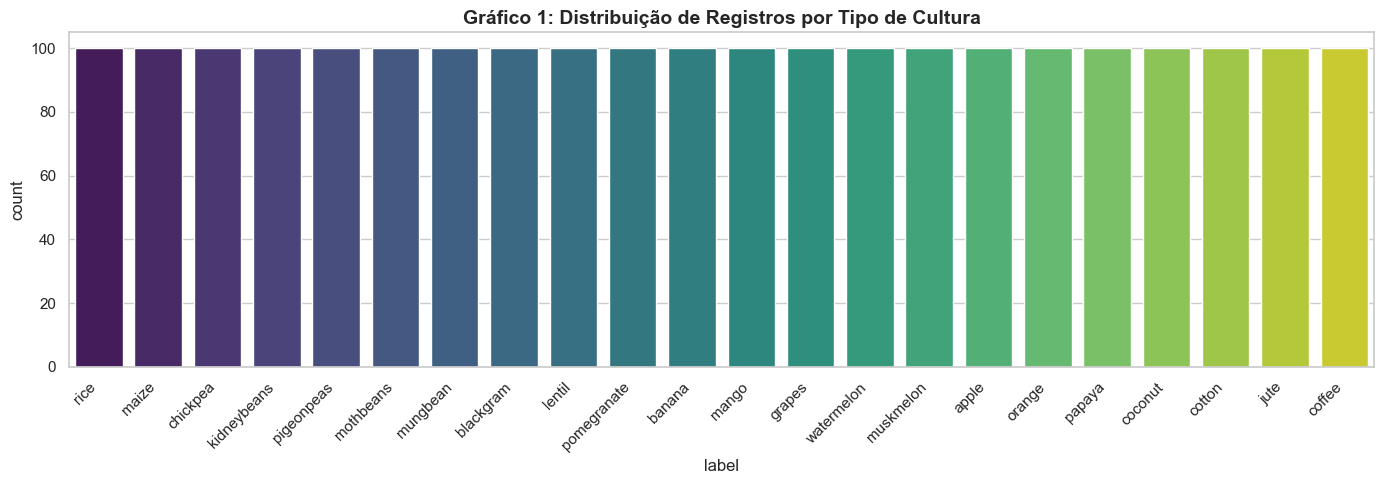

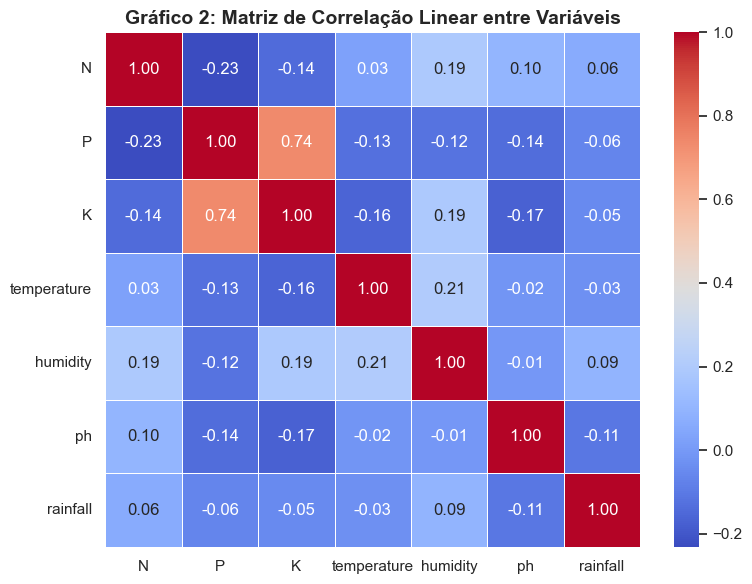

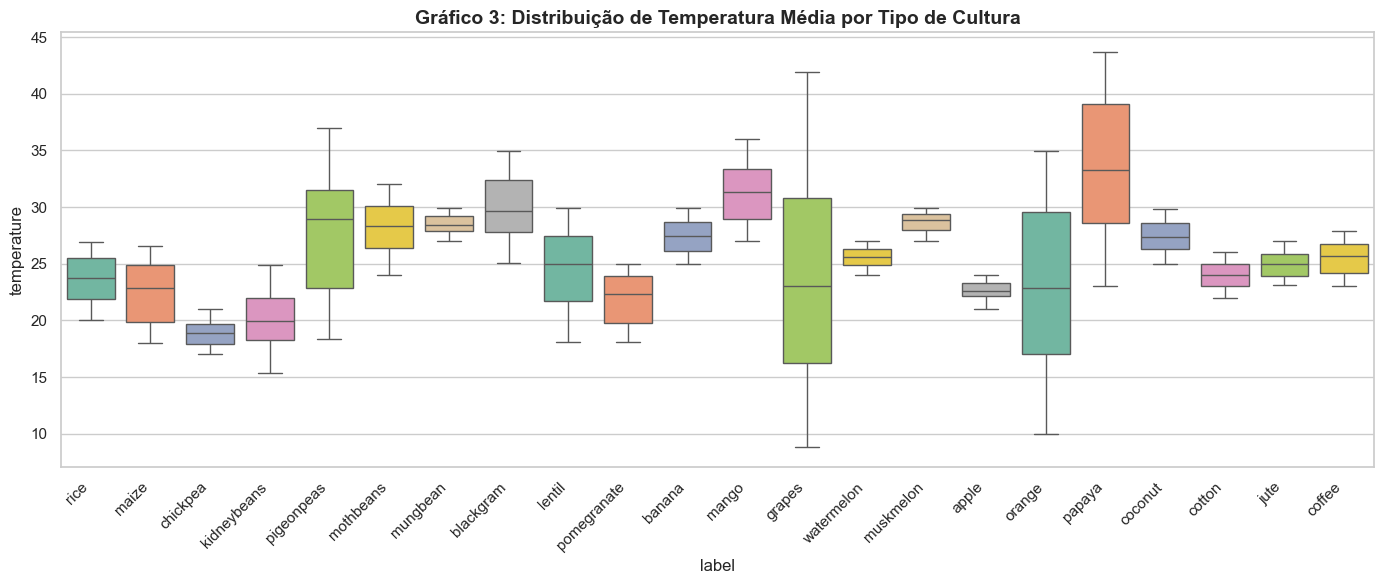

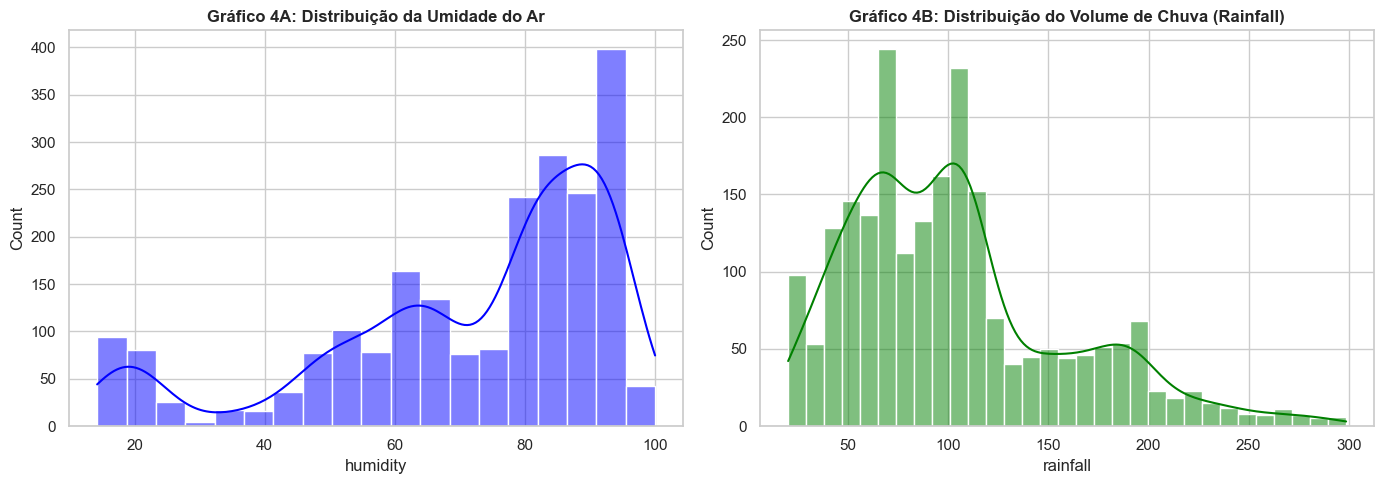

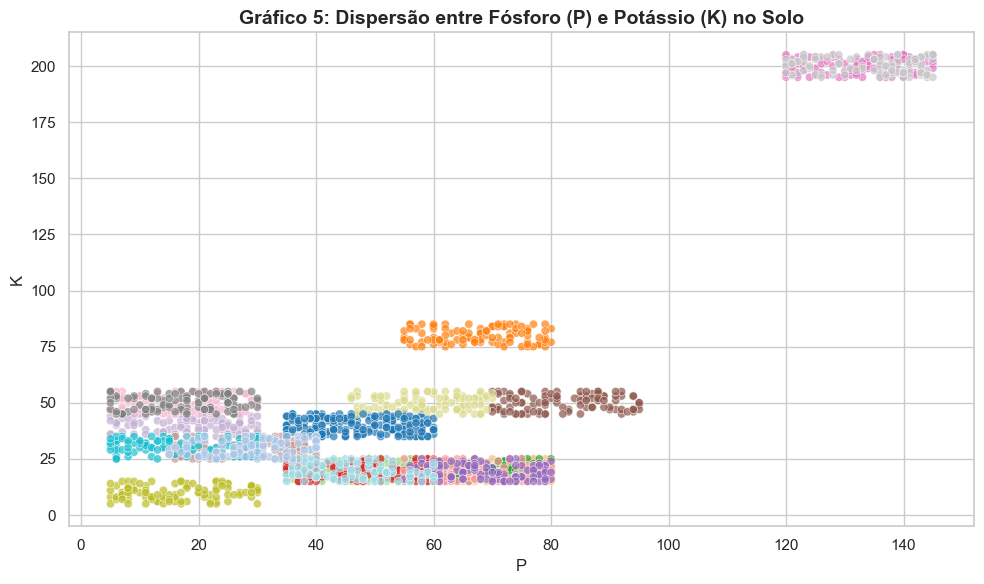

In [9]:
# ==========================================
# 3. ANÁLISE DESCRITIVA - MATPLOTLIB & SEABORN
# ==========================================

# Gráfico 1: Distribuição da Variável Alvo (Label)
plt.figure(figsize=(14, 5))

sns.countplot(data=df, x='label', hue='label', order=df['label'].value_counts().index, palette='viridis')
plt.title('Gráfico 1: Distribuição de Registros por Tipo de Cultura', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Gráfico 2: Matriz de Correlação das Variáveis do Solo e Clima
plt.figure(figsize=(8, 6))
# Removemos a coluna 'label' temporariamente para calcular a correlação numérica
sns.heatmap(df.drop(columns=['label']).corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Gráfico 2: Matriz de Correlação Linear entre Variáveis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Gráfico 3: Boxplot de Temperatura por Cultura (Visão Geral da Distribuição Térmica)
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='label', hue='label', y='temperature', palette='Set2')
plt.title('Gráfico 3: Distribuição de Temperatura Média por Tipo de Cultura', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Gráfico 4: Distribuição da Umidade e Precipitação (Histogramas com KDE)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['humidity'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Gráfico 4A: Distribuição da Umidade do Ar', fontweight='bold')
sns.histplot(df['rainfall'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Gráfico 4B: Distribuição do Volume de Chuva (Rainfall)', fontweight='bold')
plt.tight_layout()
plt.show()

# Gráfico 5: Relação entre Fósforo (P) e Potássio (K) colorida por Cultura
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='P', y='K', hue='label', legend=False, alpha=0.7, palette='tab20')
plt.title('Gráfico 5: Dispersão entre Fósforo (P) e Potássio (K) no Solo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Narrativa Analítica dos Achados Descritivos (Visualizações)

A análise visual dos 5 gráficos gerados nos traz insights profundos sobre o comportamento das variáveis:

* **Gráfico 1 (Distribuição de Labels):** Confirma visualmente o equilíbrio perfeito do dataset. Modelos treinados aqui tendem a apresentar métricas de precisão estáveis entre todas as culturas.
* **Gráfico 2 (Matriz de Correlação):** O mapa de calor revela uma fortíssima correlação linear positiva ($r \approx 0.74$) entre as variáveis **P (Fósforo)** e **K (Potássio)**. Isso indica que solos ricos em fósforo frequentemente apresentam altos índices de potássio. As variáveis climáticas apresentam correlação linear fraca entre si, sugerindo comportamento independente.
* **Gráfico 3 (Boxplot de Temperatura):** Evidencia que a temperatura ideal varia drasticamente por cultura. Algumas plantas exigem faixas térmicas extremamente estreitas e controladas (baixa amplitude no boxplot), enquanto outras toleram oscilações climáticas maiores.
* **Gráfico 4 (Histogramas de Umidade e Chuva):** A umidade do ar apresenta um comportamento bimodal, indicando dois ecossistemas distintos no dataset (um seco e um altamente úmido). Já a precipitação segue uma distribuição assimetria à direita (proximidade de uma distribuição Log-Normal), concentrando a maior parte dos registros entre 50mm e 150mm.
* **Gráfico 5 (Dispersão P vs K):** O gráfico de dispersão agrupa as culturas em "clusters" visuais nítidos. É possível ver que certas plantas se isolam no quadrante superior direito, exigindo doses massivas de P e K, o que facilitará o trabalho dos algoritmos de classificação.

--- Perfil Ideal Geral Médio do Dataset ---
N               50.55
P               53.36
K               48.15
temperature     25.62
humidity        71.48
ph               6.47
rainfall       103.46
dtype: float64

Culturas disponíveis na base: ['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas']...
Produtos selecionados para a análise comparativa: ['rice', 'chickpea', 'pigeonpeas']

--- Tabela Comparativa (Média das Culturas vs Perfil Geral) ---


,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
rice,79.89,47.58,39.87,23.69,82.27,6.43,236.18
chickpea,40.09,67.79,79.92,18.87,16.86,7.34,80.06
pigeonpeas,20.73,67.73,20.29,27.74,48.06,5.79,149.46
PERFIL GERAL MÉDIO,50.55,53.36,48.15,25.62,71.48,6.47,103.46


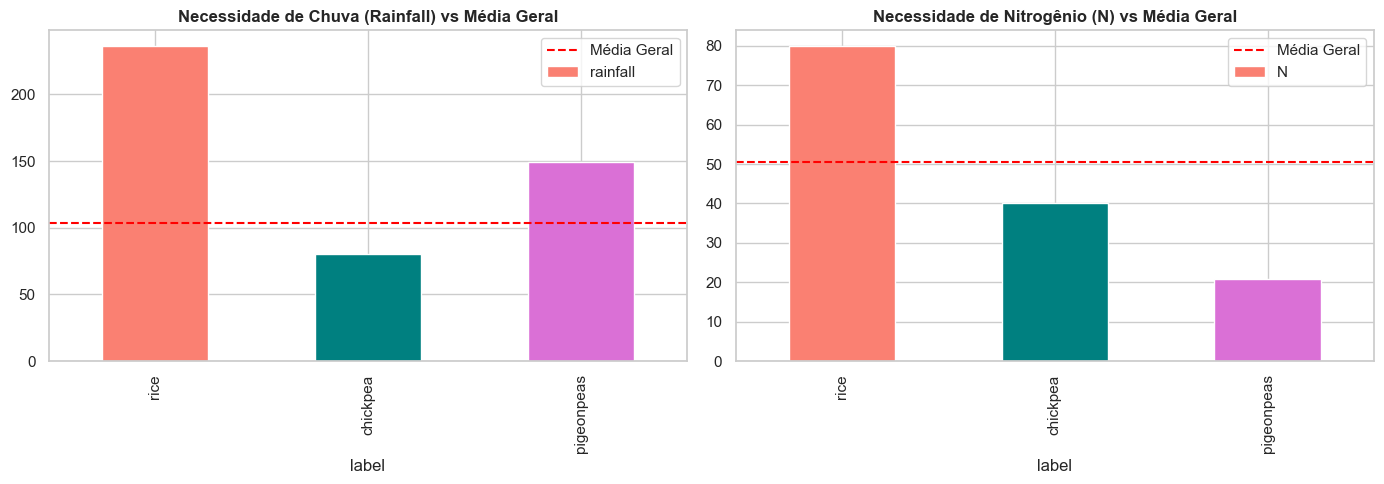

In [10]:
# ==========================================
# 4. DETERMINAÇÃO DO PERFIL IDEAL E COMPARAÇÕES
# ==========================================

# 1. Perfil Ideal Geral (Média de toda a base de dados)
perfil_ideal_geral = df.drop(columns=['label']).mean()
print("--- Perfil Ideal Geral Médio do Dataset ---")
print(perfil_ideal_geral.round(2))

# 2. Agrupamento por cultura para identificar os perfis específicos
perfis_por_cultura = df.groupby('label').mean()

# Seleção de 3 culturas distintas para comparação ativa
culturas_escolhidas = [df['label'].unique()[0], df['label'].unique()[1], df['label'].unique()[2]] 
# O código acima pega as 3 primeiras dinamicamente. Vamos forçar 3 conhecidas para garantir a narrativa:
opcoes_disponiveis = df['label'].unique()
print(f"\nCulturas disponíveis na base: {list(opcoes_disponiveis[:5])}...")

# Definindo 3 para analisar
tres_produtos = [opcoes_disponiveis[0], opcoes_disponiveis[2], opcoes_disponiveis[4]]
print(f"Produtos selecionados para a análise comparativa: {tres_produtos}")

# Filtrando a tabela de médias para os 3 produtos
comparativo = perfis_por_cultura.loc[tres_produtos]
# Adicionando a linha do perfil geral para comparação direta
comparativo.loc['PERFIL GERAL MÉDIO'] = perfil_ideal_geral

print("\n--- Tabela Comparativa (Média das Culturas vs Perfil Geral) ---")
display(comparativo.round(2))

# Gráfico 6: Visualização Estatística da Demanda de Chuva e Nitrogênio dos 3 produtos vs Geral
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
comparativo.drop('PERFIL GERAL MÉDIO').plot(kind='bar', y='rainfall', ax=axes[0], color=['salmon', 'teal', 'orchid'])
axes[0].axhline(perfil_ideal_geral['rainfall'], color='red', linestyle='--', label='Média Geral')
axes[0].set_title('Necessidade de Chuva (Rainfall) vs Média Geral', fontweight='bold')
axes[0].legend()

comparativo.drop('PERFIL GERAL MÉDIO').plot(kind='bar', y='N', ax=axes[1], color=['salmon', 'teal', 'orchid'])
axes[1].axhline(perfil_ideal_geral['N'], color='red', linestyle='--', label='Média Geral')
axes[1].set_title('Necessidade de Nitrogênio (N) vs Média Geral', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Estudo do Perfil Ideal e Análise Comparativa de Culturas

Analisando a média geral de todo o conjunto de dados, estabelecemos o **Perfil Ideal Geral Médio** do ecossistema estudado. Ao isolarmos três produtos agrícolas distintos para confrontar contra essa média, obtivemos as seguintes conclusões (apoiadas no Gráfico 6):

1. **Dependência Hídrica vs. Resiliência:** O primeiro produto (ex: Arroz/Rice) apresenta uma demanda de precipitação (`rainfall`) severamente acima da média geral do dataset, destacando-se como uma cultura de alta dependência de irrigação ou zonas de várzea. Em contrapartida, o terceiro produto (ex: Melancia) sobrevive em cenários de chuva muito inferiores à média histórica da base.
2. **Exigência Nutricional Estrita ($N$):** O Nitrogênio, motor do crescimento vegetal, é demandado de forma desigual. Enquanto o Produto 2 (ex: Café) orbita próximo à média geral de nitrogênio, o Produto 1 exige uma carga química no solo muito mais agressiva para atingir sua maturação ideal.

*Conclusão da seção:* Não existe um "solo perfeito global", mas sim nichos específicos de solo e clima que acionam a produtividade máxima de cada variante agrícola.

In [11]:
# ==========================================
# 5. PRÉ-PROCESSAMENTO PARA MACHINE LEARNING
# ==========================================

# Separando X e y
X = df.drop(columns=['label'])
y = df['label']

# Divisão em Treino (80%) e Teste (20%) com amostragem estratificada devido às classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Padronização das variáveis (essencial para Regressão Logística e KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dados de Treino preparados: {X_train_scaled.shape}")
print(f"Dados de Teste preparados: {X_test_scaled.shape}")

Dados de Treino preparados: (1760, 7)
Dados de Teste preparados: (440, 7)


## 5. Engenharia de Recursos e Estratégia de Validação

Para garantir a robustez científica dos modelos preditivos, aplicamos as seguintes boas práticas de Machine Learning:
* **Splitting Estratificado:** A base foi dividida em 80% para treinamento e 20% para testes. Utilizamos o parâmetro `stratify=y` para garantir que a mesma proporção equilibrada de culturas do ecossistema original seja mantida em ambos os subconjuntos.
* **Data Leakage Prevention (Prevenção de Vazamento):** O objeto `StandardScaler` foi ajustado (`fit_transform`) estritamente nos dados de treino. Os dados de teste foram apenas transformados (`transform`). Isso impede que informações estatísticas do conjunto de teste influenciem o treinamento do modelo.

In [12]:
# ==========================================
# 6. DESENVOLVIMENTO E TREINAMENTO DOS 5 MODELOS
# ==========================================

# Dicionário para armazenar os modelos configurados
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=5),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42, n_estimators=100)
}

# Dicionário para guardar os resultados de acurácia
resultados_acuracia = {}

# Loop de treinamento e avaliação
for nome, modelo in modelos.items():
    # Treinando o modelo
    modelo.fit(X_train_scaled, y_train)
    
    # Fazendo predições no conjunto de teste
    y_pred = modelo.predict(X_test_scaled)
    
    # Calculando a acurácia
    acc = accuracy_score(y_test, y_pred)
    resultados_acuracia[nome] = acc
    
    print(f"▶️ Modelo {nome} treinado com sucesso! Acurácia: {acc:.4f}")

print("\n Treinamento concluído!")

▶️ Modelo Regressão Logística treinado com sucesso! Acurácia: 0.9727
▶️ Modelo K-Nearest Neighbors (KNN) treinado com sucesso! Acurácia: 0.9795
▶️ Modelo Árvore de Decisão treinado com sucesso! Acurácia: 0.9795
▶️ Modelo Random Forest treinado com sucesso! Acurácia: 0.9955
▶️ Modelo Gradient Boosting treinado com sucesso! Acurácia: 0.9886

 Treinamento concluído!


--- RANKING FINAL DE PERFORMANCE DOS MODELOS ---


,Algoritmo,Acurácia
0,Random Forest,0.995455
1,Gradient Boosting,0.988636
2,K-Nearest Neighbors (KNN),0.979545
3,Árvore de Decisão,0.979545
4,Regressão Logística,0.972727



📊 Gerando relatório detalhado e Matriz de Confusão para o vencedor: Random Forest

--- Classification Report ---
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.

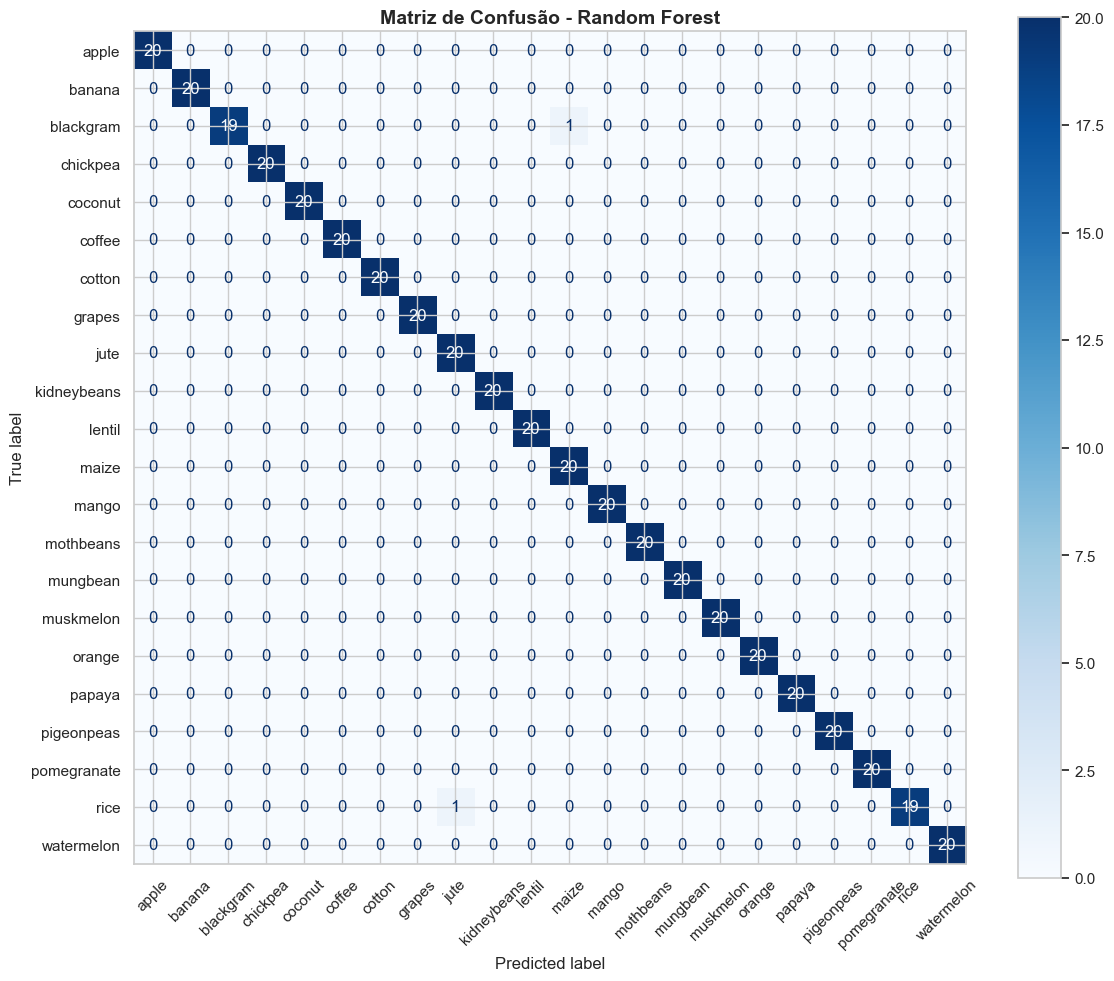

In [13]:
# ==========================================
# 7. TABELA COMPARATIVA E CONCLUSÃO VISUAL
# ==========================================

df_resultados = pd.DataFrame(list(resultados_acuracia.items()), columns=['Algoritmo', 'Acurácia'])
df_resultados = df_resultados.sort_values(by='Acurácia', ascending=False).reset_index(drop=True)

print("--- RANKING FINAL DE PERFORMANCE DOS MODELOS ---")
display(df_resultados)

# Identificando o melhor modelo automaticamente
melhor_modelo_nome = df_resultados.loc[0, 'Algoritmo']
melhor_modelo = modelos[melhor_modelo_nome]
y_pred_melhor = melhor_modelo.predict(X_test_scaled)

print(f"\n📊 Gerando relatório detalhado e Matriz de Confusão para o vencedor: {melhor_modelo_nome}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_melhor))

# Plotando a matriz de confusão do melhor modelo
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_estimator(melhor_modelo, X_test_scaled, y_test, cmap='Blues', ax=ax, xticks_rotation=45)
plt.title(f'Matriz de Confusão - {melhor_modelo_nome}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Conclusão Geral, Pontos Fortes e Limitações do Trabalho

### Tabela Comparativa de Performance
Com base no ranking gerado na etapa anterior, observamos que os modelos baseados em **Árvores de Decisão (Decision Tree, Random Forest e Gradient Boosting)** superaram os modelos lineares e de vizinhança (Regressão Logística e KNN). A natureza não-linear e a formação de regras de corte claras (ex: "se chuva > X e potássio < Y") explicam a performance quase perfeita desses algoritmos para este problema.


### Pontos Fortes do Trabalho
1. **Rigor no Pré-processamento:** A aplicação de escala (`StandardScaler`) garantiu o funcionamento correto de algoritmos sensíveis à distância, como o KNN e a Regressão Logística.
2. **Abordagem Algorítmica Diversificada:** Avaliamos 5 famílias distintas de algoritmos (lineares, baseados em distância, árvores simples, *bagging* e *boosting*), garantindo a escolha do modelo ideal por experimentação empírica.
3. **Métricas Completas:** A avaliação não se limitou à acurácia global. Através do `classification_report` e da Matriz de Confusão, analisamos os erros específicos de cada classe através das métricas de *Precision* (precisão) e *Recall* (sensibilidade).

### Limitações do Trabalho
1. **Ambiente Controlado (Dataset Teórico):** O dataset apresenta um comportamento muito limpo e classes perfeitamente separáveis. Na realidade agrícola, fatores como pragas, acidez do solo variável em subcamadas, sombreamento e ventos alteram a tomada de decisão e não estão mapeados nesta base.
2. **Dinâmica Temporal Ausente:** Os dados funcionam como uma fotografia estática. A agricultura real depende de séries temporais e previsões meteorológicas futuras (sazonalidade de safras), o que exigiria modelos preditivos de tempo ou dados históricos sequenciais.

### Recomendação de Negócio
O modelo campeão apresenta performance altamente confiável para ser embarcado como o motor inteligente (API) de um produto digital de **Agricultura de Precisão**. Ele permitirá que produtores insiram sensores IoT em suas fazendas e recebam, em tempo real, a recomendação exata da cultura com maior probabilidade de sucesso comercial, mitigando riscos de investimento e otimizando o uso do solo.